In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sgp4.api import accelerated
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
import requests
import json
import os
from dotenv import load_dotenv

In [2]:
print(accelerated)

True


In [3]:
tle_data = []

In [4]:
load_dotenv()
url = os.getenv ("tle_url")
page = requests.get(url)
content = page.json()["data"]["tles"]

for i in content:
    name = i.get('name')
    firstLine = i.get('firstLine')
    secondLine = i.get('secondLine')
    tle_data.append((name, firstLine, secondLine))

In [5]:
print(f"Fetched {len(tle_data)} TLE entries.")

Fetched 27774 TLE entries.


In [6]:
import pandas as pd

df = pd.DataFrame(tle_data, columns=['name', 'firstLine', 'secondLine'])
print(df.head(15))

                      name                                          firstLine  \
0               VANGUARD 2  1    11U 59001A   25321.78475295  .00000797  0...   
1             VANGUARD R/B  1    12U 59001B   25321.85725360  .00001916  0...   
2               VANGUARD 3  1 00020U 59007A   25321.27955887  .00003548  0...   
3               EXPLORER 7  1    22U 59009A   25321.85377756  .00013039  0...   
4                  TIROS 1  1    29U 60002B   25321.68434838  .00001327  0...   
5               TRANSIT 2A  1    45U 60007A   25321.62134728  .00000650  0...   
6          SOLRAD 1 (GREB)  1    46U 60007B   25321.76925900  .00001512  0...   
7        THOR ABLESTAR R/B  1    47U 60007C   25321.82383591  .00001240  0...   
8              DELTA 1 R/B  1    50U 60009B   25321.73532257 -.00000111  0...   
9   ECHO 1 DEB (METAL OBJ)  1    51U 60009C   25321.75152269 -.00000067  0...   
10  ECHO 1 DEB (METAL OBJ)  1    53U 60009E   25321.61523810 -.00000036  0...   
11              COURIER 1B  

In [7]:
head_15 =  tle_data[:15] # Store the first 15 TLE entries in a variable

In [8]:
from sgp4.api import Satrec

satellites_satrec = [] #contains the satellite name and its satrec object

for name, firstline, secondline in head_15:
    sat = Satrec.twoline2rv(firstline, secondline)
    satellites_satrec.append((name, sat))

In [ ]:
#for testing actually:

# The Satrec object has the epoch stored:
print(sat.epochyr)   # Year
print(sat.epochdays) # Day of year with fraction
print(sat.jdsatepoch) # Julian date of epoch

25
321.75034817
2460996.5


In [10]:
for name, sat in satellites_satrec:
    print(f"""Satelite Name :{name}
          Satrec Epoch Year: {sat.epochyr} 
          Satrec Epoch Day: {sat.epochdays} 
          Satrec Julian Date: {sat.jdsatepoch}""")

Satelite Name :VANGUARD 2
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.78475295 
          Satrec Julian Date: 2460996.5
Satelite Name :VANGUARD R/B
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.8572536 
          Satrec Julian Date: 2460996.5
Satelite Name :VANGUARD 3
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.27955887 
          Satrec Julian Date: 2460996.5
Satelite Name :EXPLORER 7
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.85377756 
          Satrec Julian Date: 2460996.5
Satelite Name :TIROS 1
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.68434838 
          Satrec Julian Date: 2460996.5
Satelite Name :TRANSIT 2A
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.62134728 
          Satrec Julian Date: 2460996.5
Satelite Name :SOLRAD 1 (GREB)
          Satrec Epoch Year: 25 
          Satrec Epoch Day: 321.769259 
          Satrec Julian Date: 2460996.5
Satelite Nam

In [11]:
#Finding the period of the satelites

for name, sat in satellites_satrec:
    mean_motion = sat.no_kozai  # Mean motion in radians per minute
    period_minutes = 2 * np.pi / mean_motion  # Period in minutes
    print(f"Satelite Name: {name}, Orbital Period: {period_minutes:.2f} minutes")

Satelite Name: VANGUARD 2, Orbital Period: 121.00 minutes
Satelite Name: VANGUARD R/B, Orbital Period: 125.40 minutes
Satelite Name: VANGUARD 3, Orbital Period: 123.98 minutes
Satelite Name: EXPLORER 7, Orbital Period: 94.55 minutes
Satelite Name: TIROS 1, Orbital Period: 97.41 minutes
Satelite Name: TRANSIT 2A, Orbital Period: 100.30 minutes
Satelite Name: SOLRAD 1 (GREB), Orbital Period: 99.01 minutes
Satelite Name: THOR ABLESTAR R/B, Orbital Period: 99.65 minutes
Satelite Name: DELTA 1 R/B, Orbital Period: 118.02 minutes
Satelite Name: ECHO 1 DEB (METAL OBJ), Orbital Period: 118.19 minutes
Satelite Name: ECHO 1 DEB (METAL OBJ), Orbital Period: 118.29 minutes
Satelite Name: COURIER 1B, Orbital Period: 106.95 minutes
Satelite Name: THOR ABLESTAR R/B, Orbital Period: 106.42 minutes
Satelite Name: SCOUT X-1 R/B, Orbital Period: 117.28 minutes
Satelite Name: EXPLORER 11, Orbital Period: 101.34 minutes


In [ ]:
from sgp4.api import jday

from astropy.time import Time
from astropy.coordinates import ITRS, TEME
from astropy import units as u

start_time = datetime.now()
time_stamped_positions = {} # to store ECI positions
time_stamped_positions_ecef = {} # to store ECEF positions

for name, sat in satellites_satrec:
    mean_motion = sat.no_kozai  # Mean motion in radians per minute
    period_minutes = 2 * np.pi / mean_motion  # Period in minutes
    end_time = start_time + timedelta(minutes = period_minutes * 1.5) 
    current_time = start_time
    while current_time <= end_time:
        jd, fr = jday(current_time.year, current_time.month, current_time.day,
                      current_time.hour, current_time.minute, current_time.second + current_time.microsecond * 1e-6)
        e, r, v = sat.sgp4(jd, fr)

        eci = TEME(x=r[0]*u.km, y=r[1]*u.km, z=r[2]*u.km, #
                    v_x=v[0]*u.km/u.s, v_y=v[1]*u.km/u.s, v_z=v[2]*u.km/u.s,
                    obstime=Time(current_time)) #
        ecef = eci.transform_to(ITRS(obstime=eci.obstime)) # Convert ECI to ECEF coordinates

        r_ecef = [ecef.x.value, ecef.y.value, ecef.z.value]
        v_ecef = [ecef.v_x.value, ecef.v_y.value, ecef.v_z.value]
        time_stamped_positions.setdefault(name, []).append((current_time, r, v))
        time_stamped_positions_ecef.setdefault(name, []).append((current_time, r_ecef, v_ecef))
        current_time += timedelta(minutes=2)
    

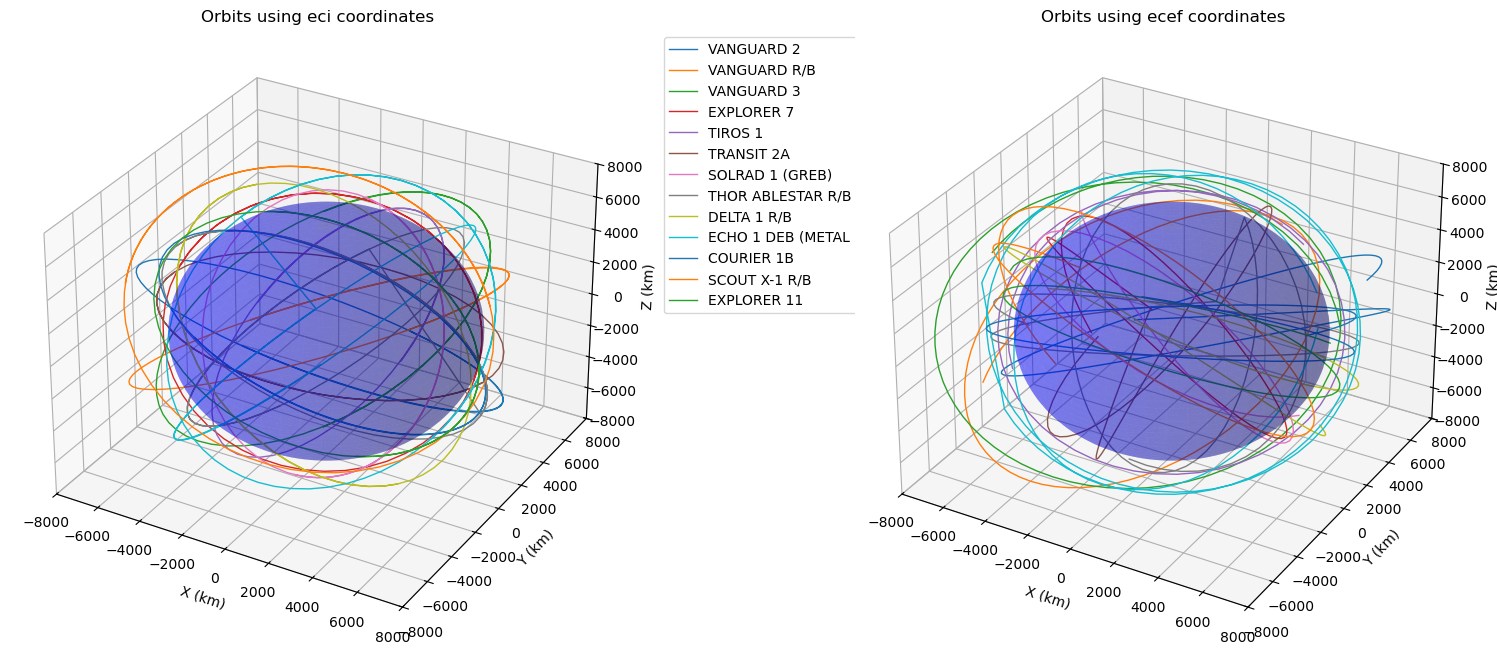

In [13]:
#plotting through each satelites;

fig = plt.figure(figsize=(20, 8))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

ax1.set_xlim([-8000, 8000])
ax1.set_ylim([-8000, 8000])
ax1.set_zlim([-8000, 8000])
ax1.set_xlabel('X (km)')
ax1.set_ylabel('Y (km)')
ax1.set_zlabel('Z (km)')
ax1.set_title('Orbits using eci coordinates')

ax2.set_xlim([-8000, 8000])
ax2.set_ylim([-8000, 8000])
ax2.set_zlim([-8000, 8000])
ax2.set_xlabel('X (km)')
ax2.set_ylabel('Y (km)')
ax2.set_zlabel('Z (km)')
ax2.set_title('Orbits using ecef coordinates')

u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))

ax1.plot_surface(x, y, z, color='b', alpha=0.3)
ax2.plot_surface(x, y, z, color='b', alpha=0.3)

for name, positions in time_stamped_positions.items():
    xs = [r[0] for current_time, r, v in positions]
    ys = [r[1] for current_time, r, v in positions]
    zs = [r[2] for current_time, r, v in positions]
    
    ax1.plot(xs, ys, zs, label=name, linewidth=1)

for name, positions in time_stamped_positions_ecef.items():
    xs = [r[0] for current_time, r, v in positions]
    ys = [r[1] for current_time, r, v in positions]
    zs = [r[2] for current_time, r, v in positions]

    
    
    ax2.plot(xs, ys, zs, label=f"{name} (ECEF)", linewidth=1)

ax1.legend(loc='upper left', bbox_to_anchor=(1.05, 1))

plt.show()